# <span style='color:purple'> 🛳️PROJECT: TITANIC SURVIVAL CLASSIFICATION

<span style='color:Maroon'> This project explores the **Titanic dataset**, one of the most famous datasets used for learning data analysis, machine learning, and predictive modeling. The dataset provides information about the passengers aboard the RMS Titanic, which sank on April 15, 1912, after colliding with an iceberg.

---

## <span style='color:Magenta'> 📘 Overview

<span style='color:maroon'> The goal of this project is to analyze the data and build predictive models to determine whether a passenger survived the disaster based on features such as:
-<span style='color:maroon'> Age  
- <span style='color:maroon'>Gender  
-<li><span style='color:maroon'>Class (1st, 2nd, or 3rd)  
- <span style='color:maroon'>Fare  
- <span style='color:maroon'>Family relations aboard (Siblings/Spouses, Parents/Children)  
- <span style='color:maroon'>Embarkation port  

---

## <span style='color:Magenta'> 📂 Dataset Description

<span style='color:maroon'> The dataset typically includes the following files:

| File | Description |
|------|--------------|
| `train.csv` | Training dataset containing passenger information and survival labels. |
| `test.csv` | Test dataset without survival labels (used for prediction). |
| `gender_submission.csv` | Sample submission file for prediction results. |

### <span style='color:green'> Columns

| Column | Description |
|--------|-------------|
| `PassengerId` | Unique ID for each passenger |
| `Survived` | Survival (0 = No, 1 = Yes) |
| `Pclass` | Ticket class (1 = 1st, 2 = 2nd, 3 = 3rd) |
| `Name` | Passenger’s full name |
| `Sex` | Gender |
| `Age` | Age in years |
| `SibSp` | Number of siblings/spouses aboard |
| `Parch` | Number of parents/children aboard |
| `Ticket` | Ticket number |
| `Fare` | Passenger fare |
| `Cabin` | Cabin number (if available) |
| `Embarked` | Port of Embarkation (C = Cherbourg, Q = Queenstown, S = Southampton) |

---

## <span style='color:Magenta'> ⚙️ Project Steps

<span style='color:Brown'>1. **Data Loading & Cleaning**  
<span style='color:maroon'>  - Handle missing values (Age, Cabin, Embarked)
<span style='color:maroon'>  - Convert categorical variables (Sex, Embarked) into numeric form

<span style='color:brown'>2. **Exploratory Data Analysis (EDA)**  
<span style='color:maroon'>   - Visualize survival rates by gender, age, and class  
<span style='color:maroon'>   - Identify correlations between features and survival  

<span style='color:brown'>3. **Feature Engineering**  
<span style='color:maroon'>   - Create new features such as `FamilySize` and `IsAlone`  
<span style='color:maroon'>   - Encode categorical variables  

<span style='color:brown'>4. **Model Building**  
<span style='color:maroon'>   - Train models (e.g., Logistic Regression, Random Forest, XGBoost)  
<span style='color:maroon'>   - Tune hyperparameters for optimal performance  

<span style='color:brown'>5. **Model Evaluation**  
<span style='color:maroon'>   - Evaluate accuracy, precision, recall, F1-score  
<span style='color:maroon'>   - Generate ROC and confusion matrix  


<span style='color:brown'>6. **Prediction & Submission**  
<span style='color:maroon'>   - Predict survival on the test set  
<span style='color:maroon'>   - Save results to `submission.csv`  

---

## <span style='color:magenta'> 🧰 Requirements

<span style='color:maroon'> Make sure you have the following installed:

```bash
python >= 3.8
pandas
numpy
matplotlib
seaborn
scikit-learn


<hr>

# <span style='color:Magenta'> Importing Libraries and Load dataset

In [201]:
# importing libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [202]:
# Load dataset
df = sns.load_dataset('titanic')

In [203]:
# Display the dataset
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [204]:
# check the information of the dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 100.4 KB


In [205]:
# Check for null values 
df.isna().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

The dataset contains null values in 'age', 'deck','embarked' and 'embark_town' feature.

## <span style='color:blue'> Fill Null Values

### <spna style='color:red'>fill null values in 'age' column


In [206]:
df['age'].unique()

array([22.  , 38.  , 26.  , 35.  ,   nan, 54.  ,  2.  , 27.  , 14.  ,
        4.  , 58.  , 20.  , 39.  , 55.  , 31.  , 34.  , 15.  , 28.  ,
        8.  , 19.  , 40.  , 66.  , 42.  , 21.  , 18.  ,  3.  ,  7.  ,
       49.  , 29.  , 65.  , 28.5 ,  5.  , 11.  , 45.  , 17.  , 32.  ,
       16.  , 25.  ,  0.83, 30.  , 33.  , 23.  , 24.  , 46.  , 59.  ,
       71.  , 37.  , 47.  , 14.5 , 70.5 , 32.5 , 12.  ,  9.  , 36.5 ,
       51.  , 55.5 , 40.5 , 44.  ,  1.  , 61.  , 56.  , 50.  , 36.  ,
       45.5 , 20.5 , 62.  , 41.  , 52.  , 63.  , 23.5 ,  0.92, 43.  ,
       60.  , 10.  , 64.  , 13.  , 48.  ,  0.75, 53.  , 57.  , 80.  ,
       70.  , 24.5 ,  6.  ,  0.67, 30.5 ,  0.42, 34.5 , 74.  ])

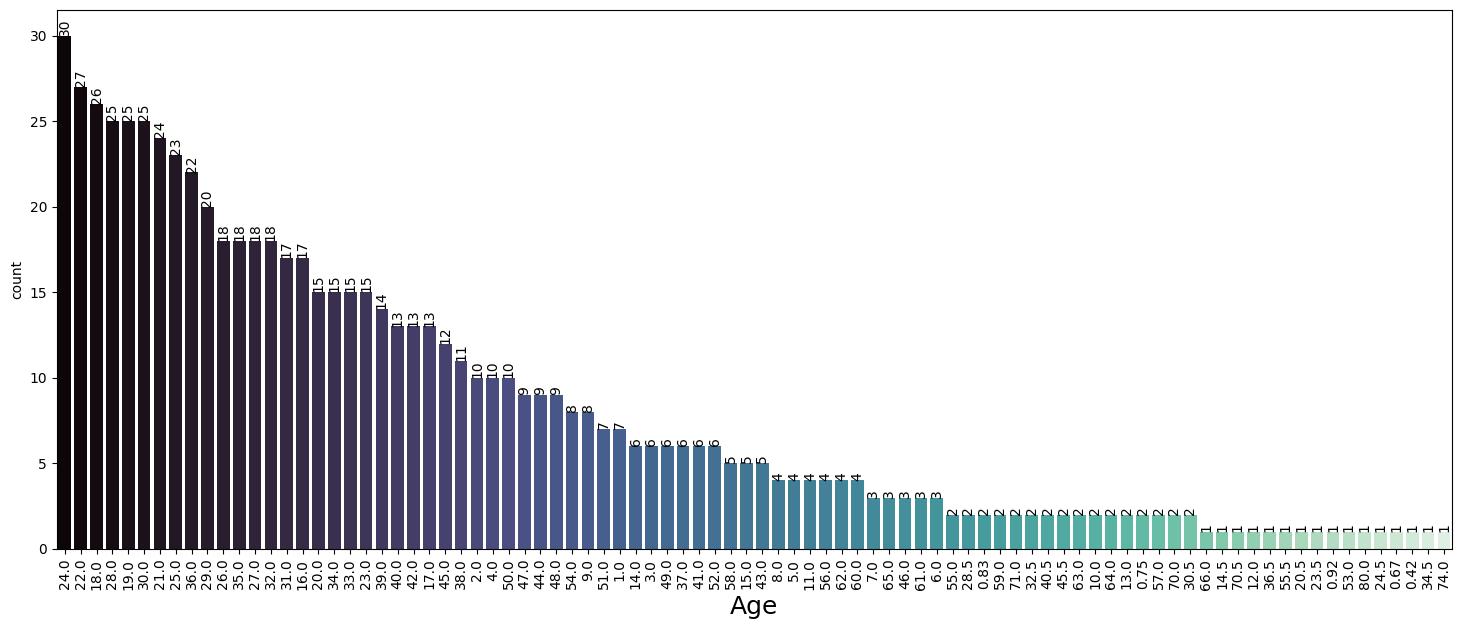

In [207]:
plt.figure(figsize=(18,7))
ax = sns.countplot(data=df, x='age', palette='mako', order=df['age'].value_counts(ascending=False).index)
for bars in ax.containers:
    ax.bar_label(bars, rotation=90)
plt.xticks(rotation=90)
plt.xlabel("Age", fontsize=18)
plt.show()

### <span style='color:magenta'> Observation:
<li><span style='color:maroon'> The people of 24 age have highest value count.
<li><span style='color:maroon'> The ages '66, 55.5, 70.5, 12, 14.5, 26.5, 20.5, .92, 23.5, 53, 80, 24.5, .67, .42, 34.5, 74' have only one value count.

In [208]:
df['age'] = df['age'].fillna(df['age'].mean())


In [209]:
df['age'].mean()

np.float64(29.69911764705882)

The mean is : 29.69 <br>
All the null values are fill with 29.69

In [210]:
df.isna().sum()

survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

Fill the null values in 'age' feature with the mean value

### <span style='color:red'> Fill null values in 'embarked' feature

In [211]:
df['embarked'].unique()

<ArrowStringArray>
['S', 'C', 'Q', nan]
Length: 4, dtype: str

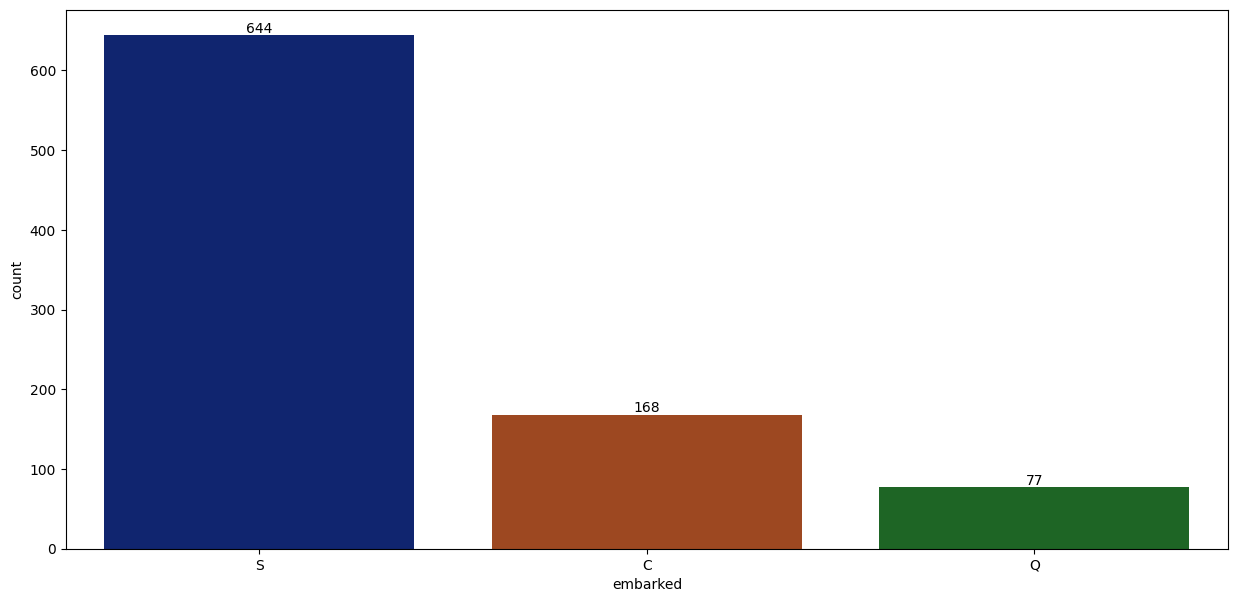

In [212]:
plt.figure(figsize=(15,7))
ax = sns.countplot(data=df, x='embarked', palette='dark')
for bars in ax.containers:
    ax.bar_label(bars)
plt.show()

In [213]:
df['embarked'].fillna("S", inplace=True)

0      S
1      C
2      S
3      S
4      S
      ..
886    S
887    S
888    S
889    C
890    Q
Name: embarked, Length: 891, dtype: str

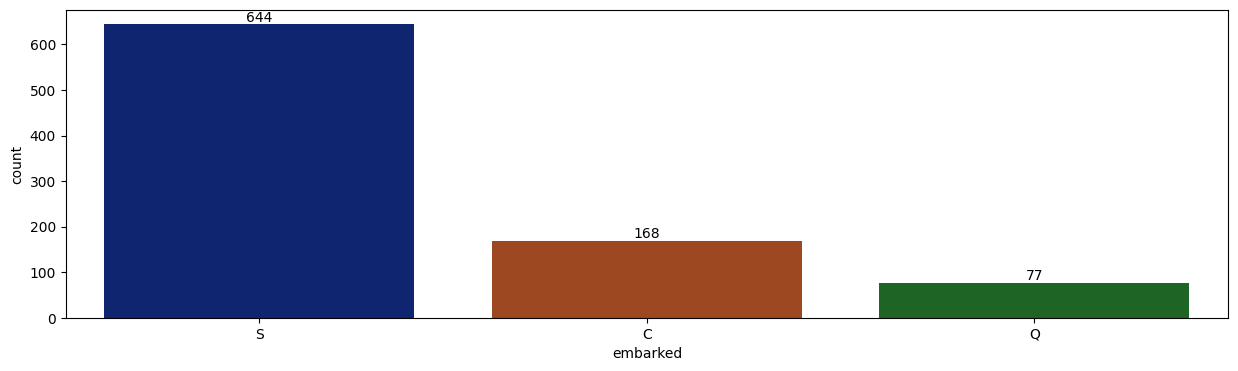

In [214]:
plt.figure(figsize=(15,4))
ax = sns.countplot(data=df, x='embarked', palette='dark')
for bars in ax.containers:
    ax.bar_label(bars)
plt.show()

## <span style='color:magenta'> Observation:
<li><span style='color:maroon'> The value count of 'S' in 'embarked' feature is higher and that of 'Q' is lower.
<li><span style='color:maroon'> The mode of the 'embarked' feature is 'S' then all the null values are filled with 'S'.

In [215]:
df.isna().sum()

survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

## <span style='color:Red'>1. Analyze the 'deck' feature

In [216]:
df['deck'].unique()

[NaN, 'C', 'E', 'G', 'D', 'A', 'B', 'F']
Categories (7, str): ['A', 'B', 'C', 'D', 'E', 'F', 'G']

### <span style='color:brown'>1.1 Countplot for deck feature

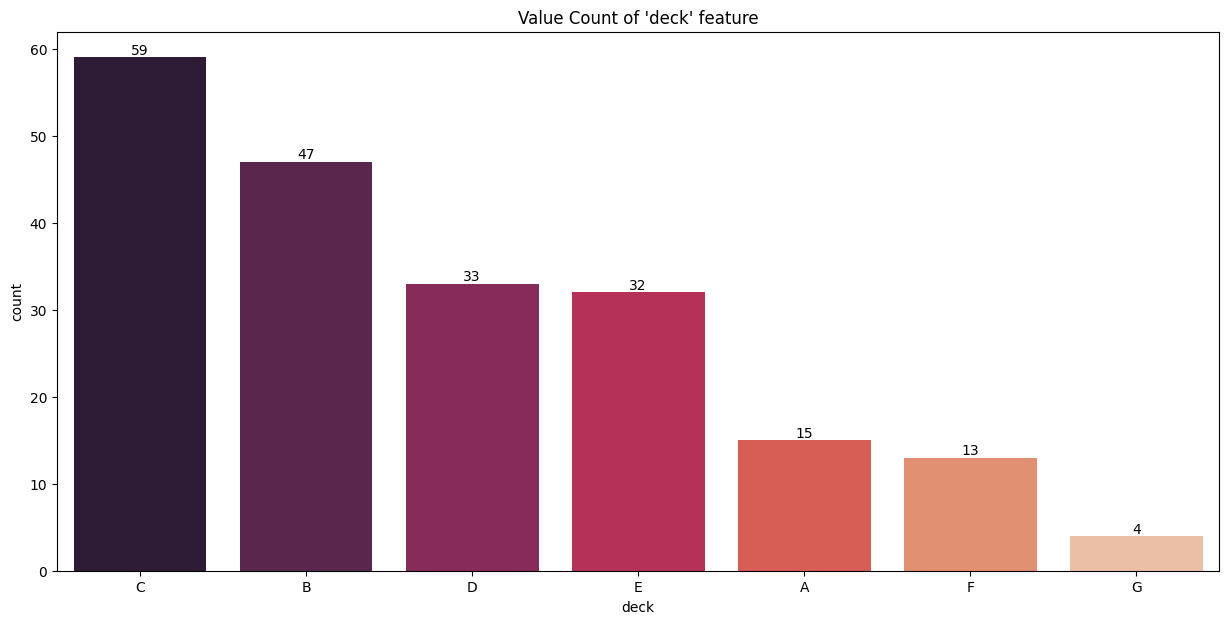

In [217]:
plt.figure(figsize=(15,7))
ax = sns.countplot(data= df, x='deck', palette='rocket', order= df['deck'].value_counts(ascending=False).index)
for bars in ax.containers:
    ax.bar_label(bars)
plt.title("Value Count of 'deck' feature", fontsize=12)
plt.show()

In [218]:
df['deck'].fillna("C", inplace=True)

0      C
1      C
2      C
3      C
4      C
      ..
886    C
887    B
888    C
889    C
890    C
Name: deck, Length: 891, dtype: category
Categories (7, str): ['A', 'B', 'C', 'D', 'E', 'F', 'G']

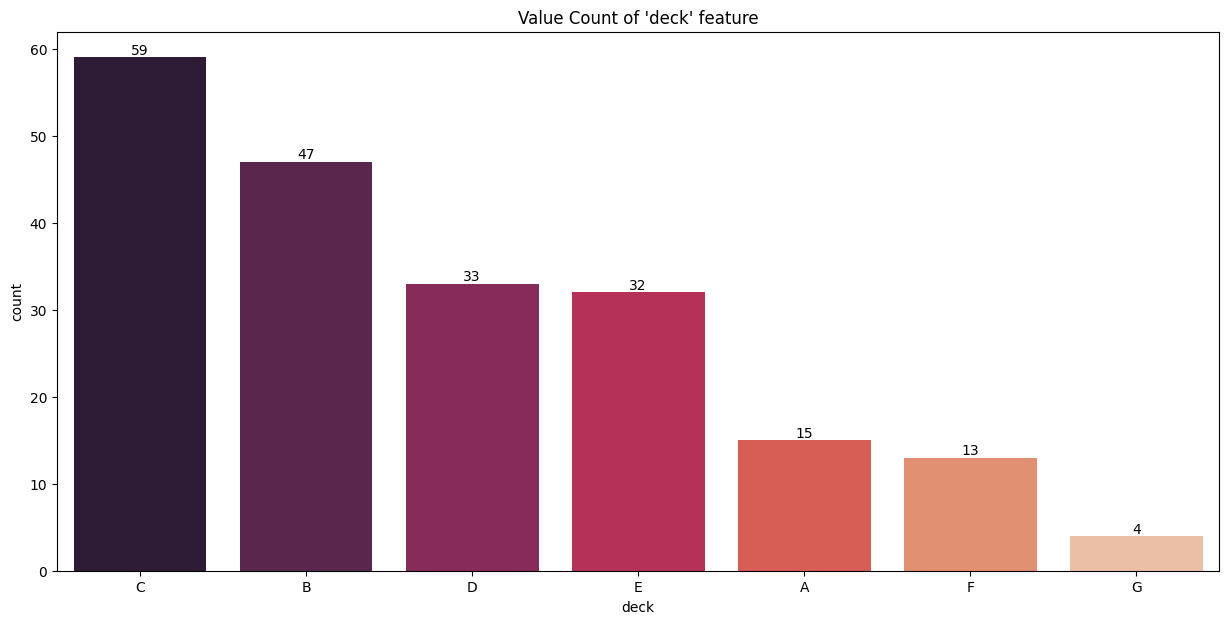

In [219]:
plt.figure(figsize=(15,7))
ax = sns.countplot(data= df, x='deck', palette='rocket', order= df['deck'].value_counts(ascending=False).index)
for bars in ax.containers:
    ax.bar_label(bars)
plt.title("Value Count of 'deck' feature", fontsize=12)
plt.show()

## Observation:
<li> All the null values are replaced with "C"
<li> The value count of "C" is greater and that of "G" is lesser.



## <span style='color:red'> Fill null values of 'embark_town' feature

In [220]:
df['embark_town'].unique()

<ArrowStringArray>
['Southampton', 'Cherbourg', 'Queenstown', nan]
Length: 4, dtype: str

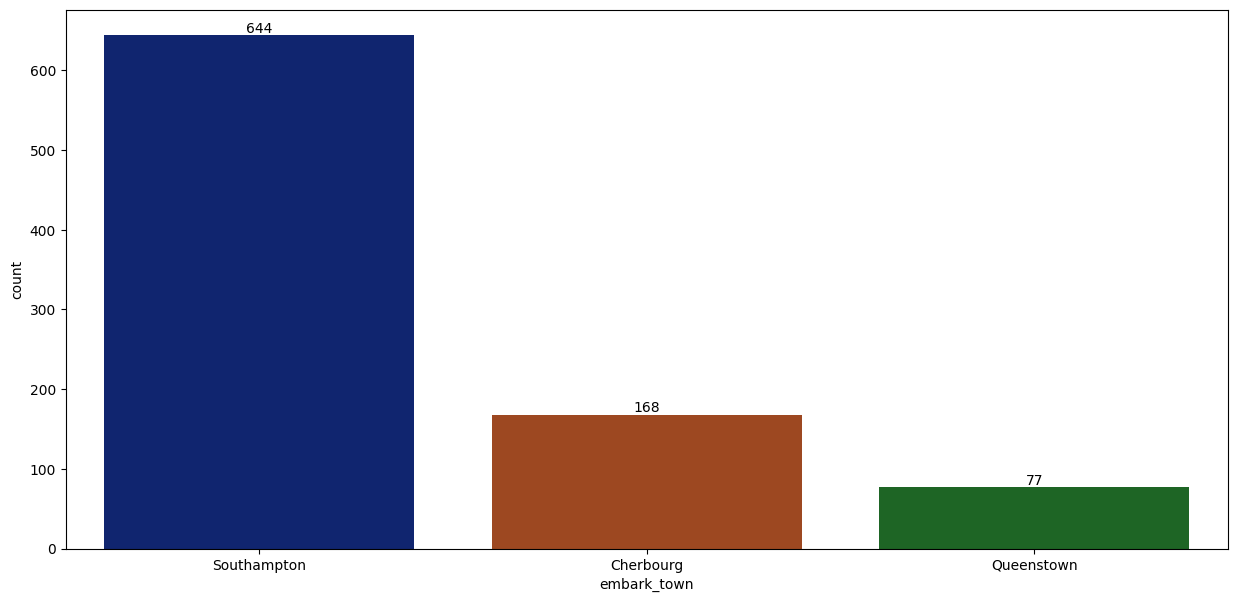

In [221]:
plt.figure(figsize=(15,7))
ax = sns.countplot(data=df, x='embark_town', palette='dark')
for bars in ax.containers:
    ax.bar_label(bars)
plt.show()

## Observation:
<li> The value_count of 'Southampton' of embark_town feature is greater and that of 'Queenstown' 
<li> The mode of the 'embark_town' feature is: 'Southampton', so all the null valuees are filled with 'Southampton'.

In [222]:
df['embark_town'].fillna("Southampton", inplace=True)

0      Southampton
1        Cherbourg
2      Southampton
3      Southampton
4      Southampton
          ...     
886    Southampton
887    Southampton
888    Southampton
889      Cherbourg
890     Queenstown
Name: embark_town, Length: 891, dtype: str

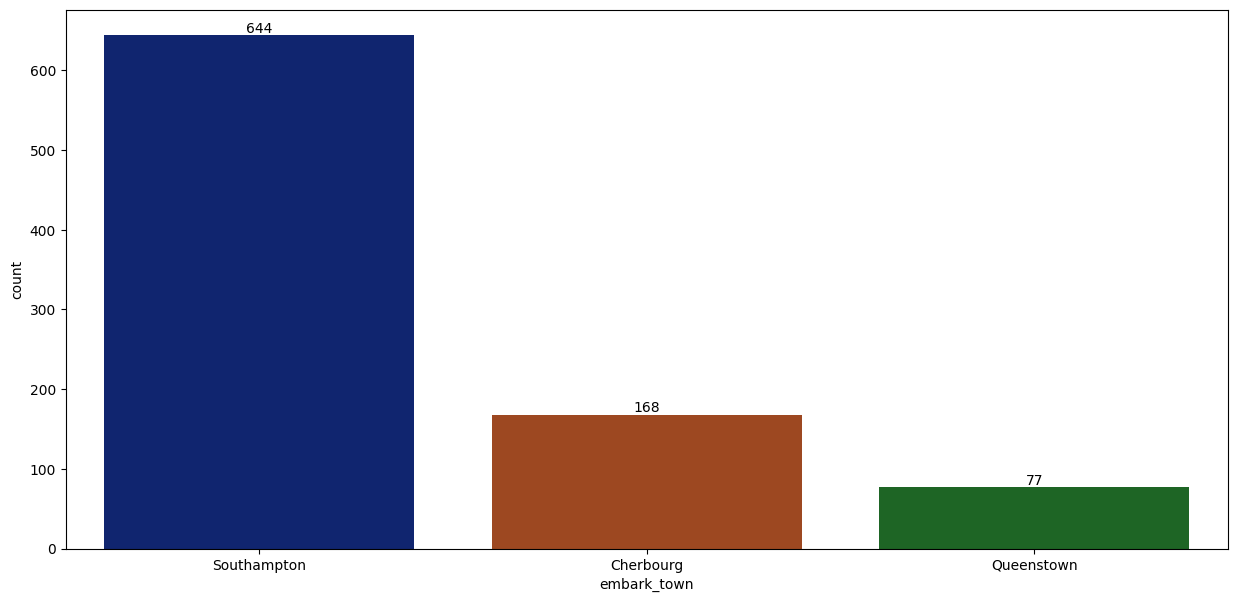

In [223]:
plt.figure(figsize=(15,7))
ax = sns.countplot(data=df, x='embark_town', palette='dark')
for bars in ax.containers:
    ax.bar_label(bars)
plt.show()

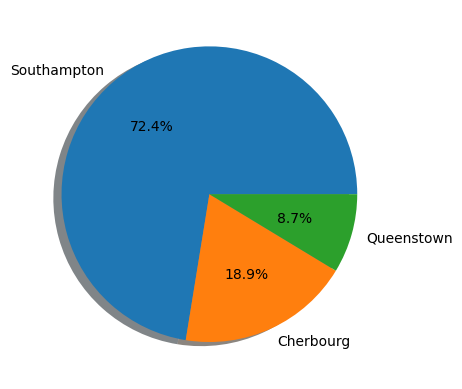

In [224]:
# Pie chart
position_count = df['embark_town'].value_counts()

plt.pie(position_count, labels=position_count.index, autopct="%1.1f%%", shadow={'ox':-0.04, 'edgecolor':'none', 'shade':0.9})
plt.show()

# <span style='color:Green'> EDA

sex


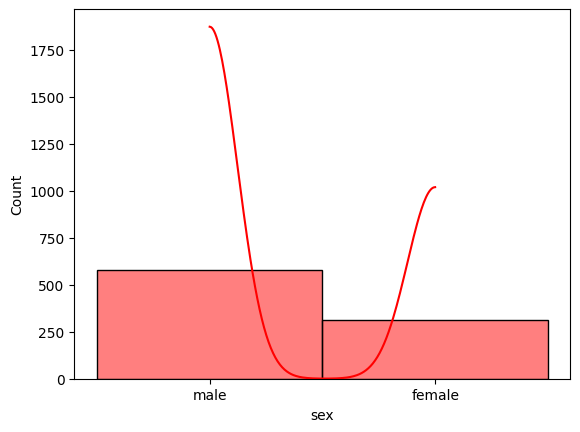

embarked


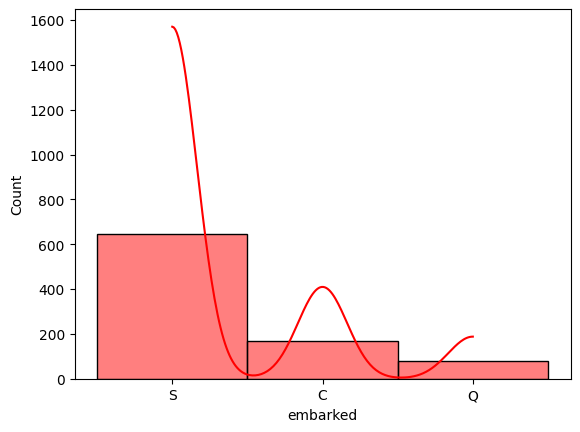

class


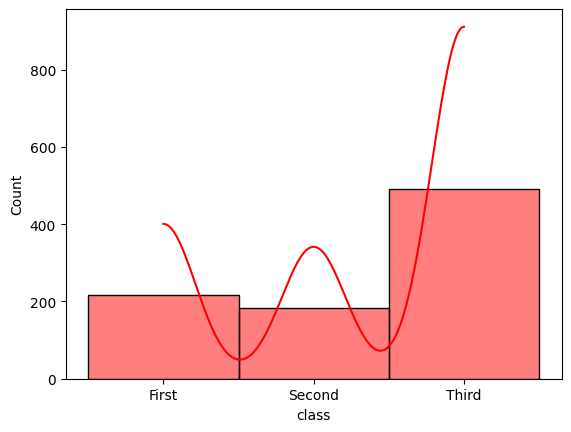

who


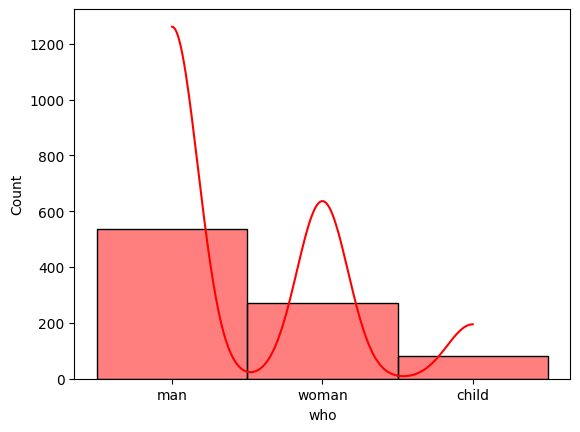

deck


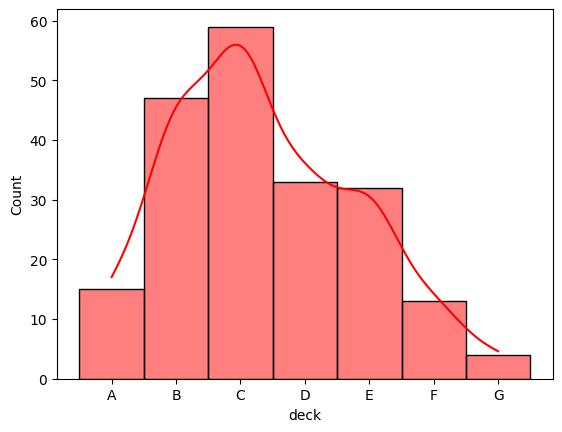

embark_town


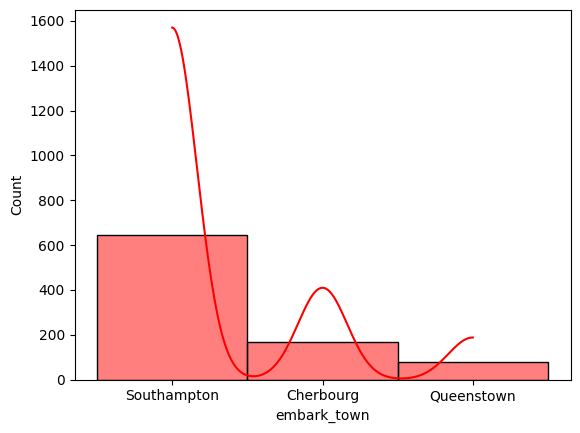

alive


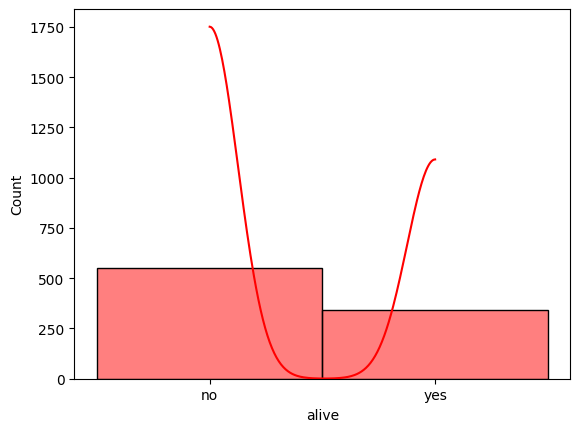

In [225]:
cat_cols = df[['sex','embarked', 'class', 'who', 'deck', 'embark_town','alive',]]
for i in cat_cols:
    colors = ['red','green','blue','skyblue','yellow','pink','orange']
    print(i)
    sns.histplot(data=cat_cols, x=i, kde=True, color='r')
    plt.show()

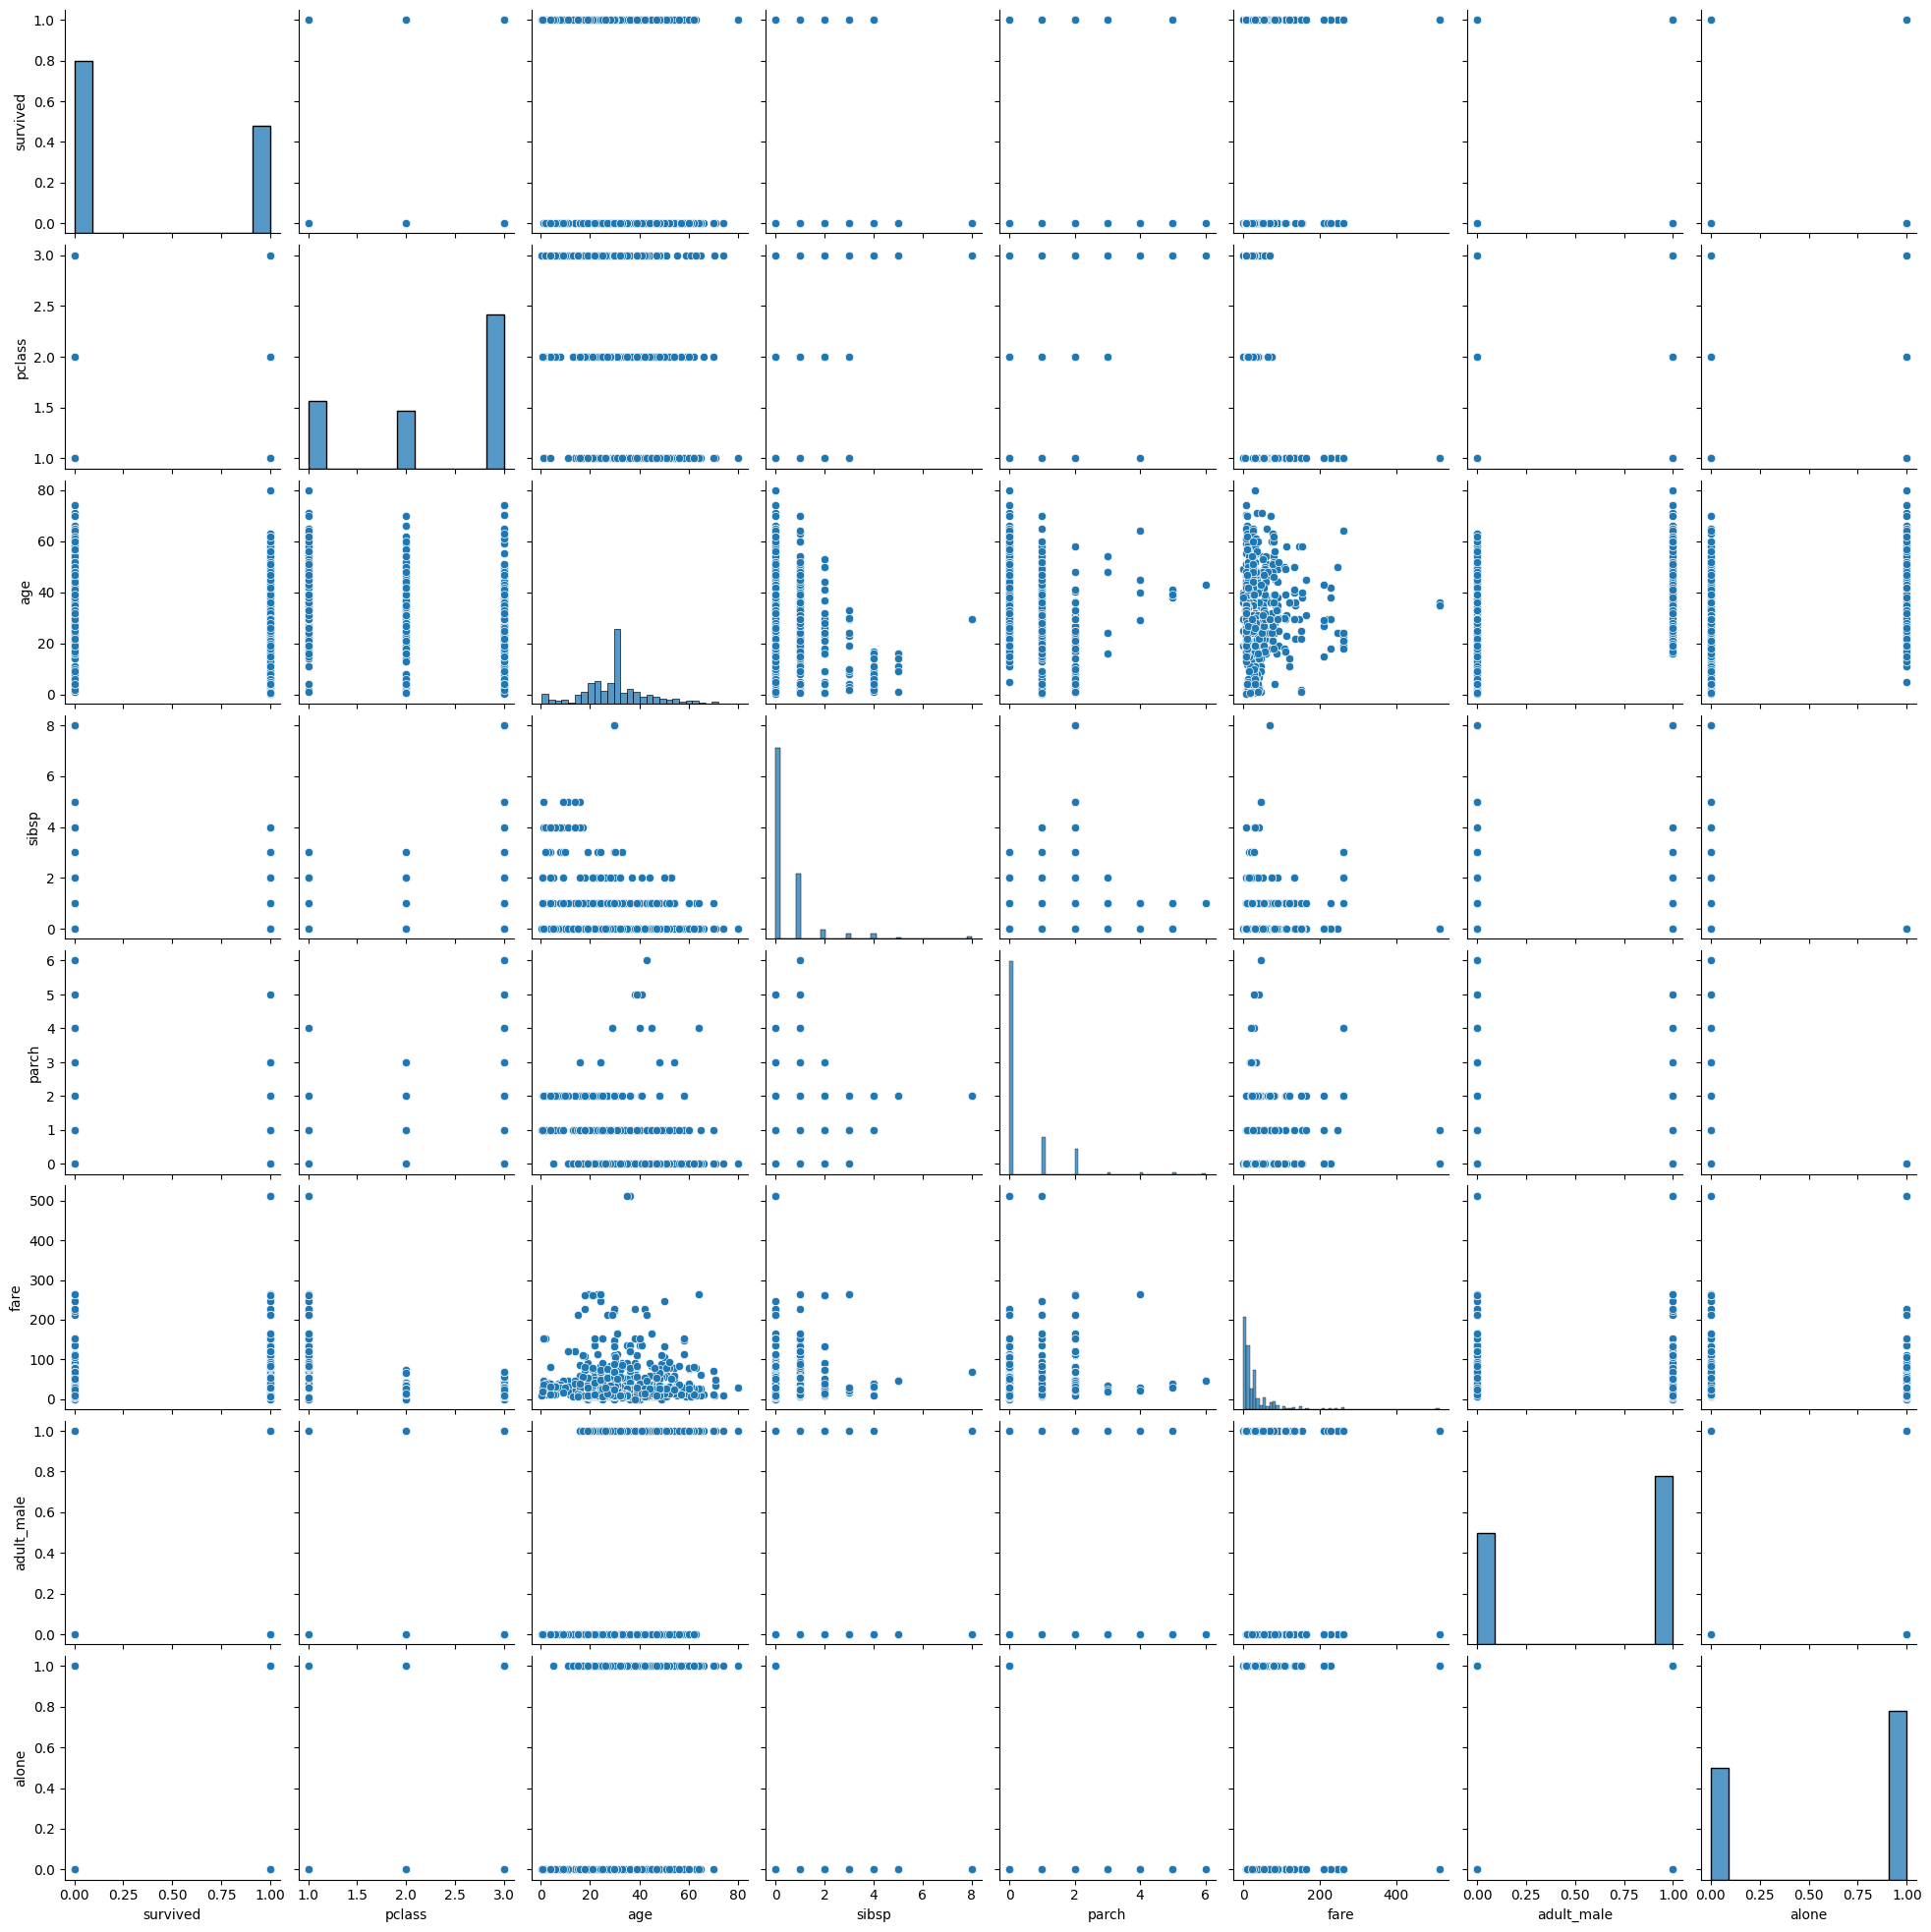

In [226]:
sns.pairplot(df)

## <span style='color:red'> Analyze the 'sex' feature with 'alive' feature

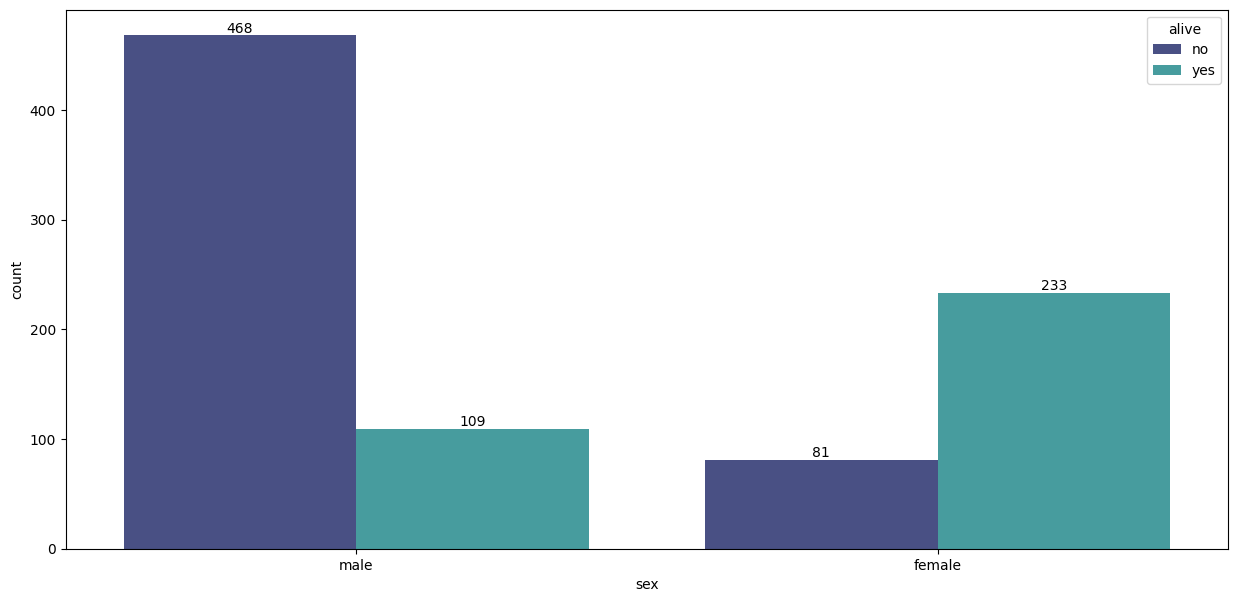

In [227]:
plt.figure(figsize=(15,7))
ax = sns.countplot(data=df, x='sex', hue='alive', palette='mako', order=df['sex'].value_counts(ascending=False).index)
for bars in ax.containers:
    ax.bar_label(bars)
plt.show()

## OBSERVATION:
<li> The value_count of non_alive is greater in males and lesse in females. 
<li> The value_count of alive is greater in females and lesse in males.

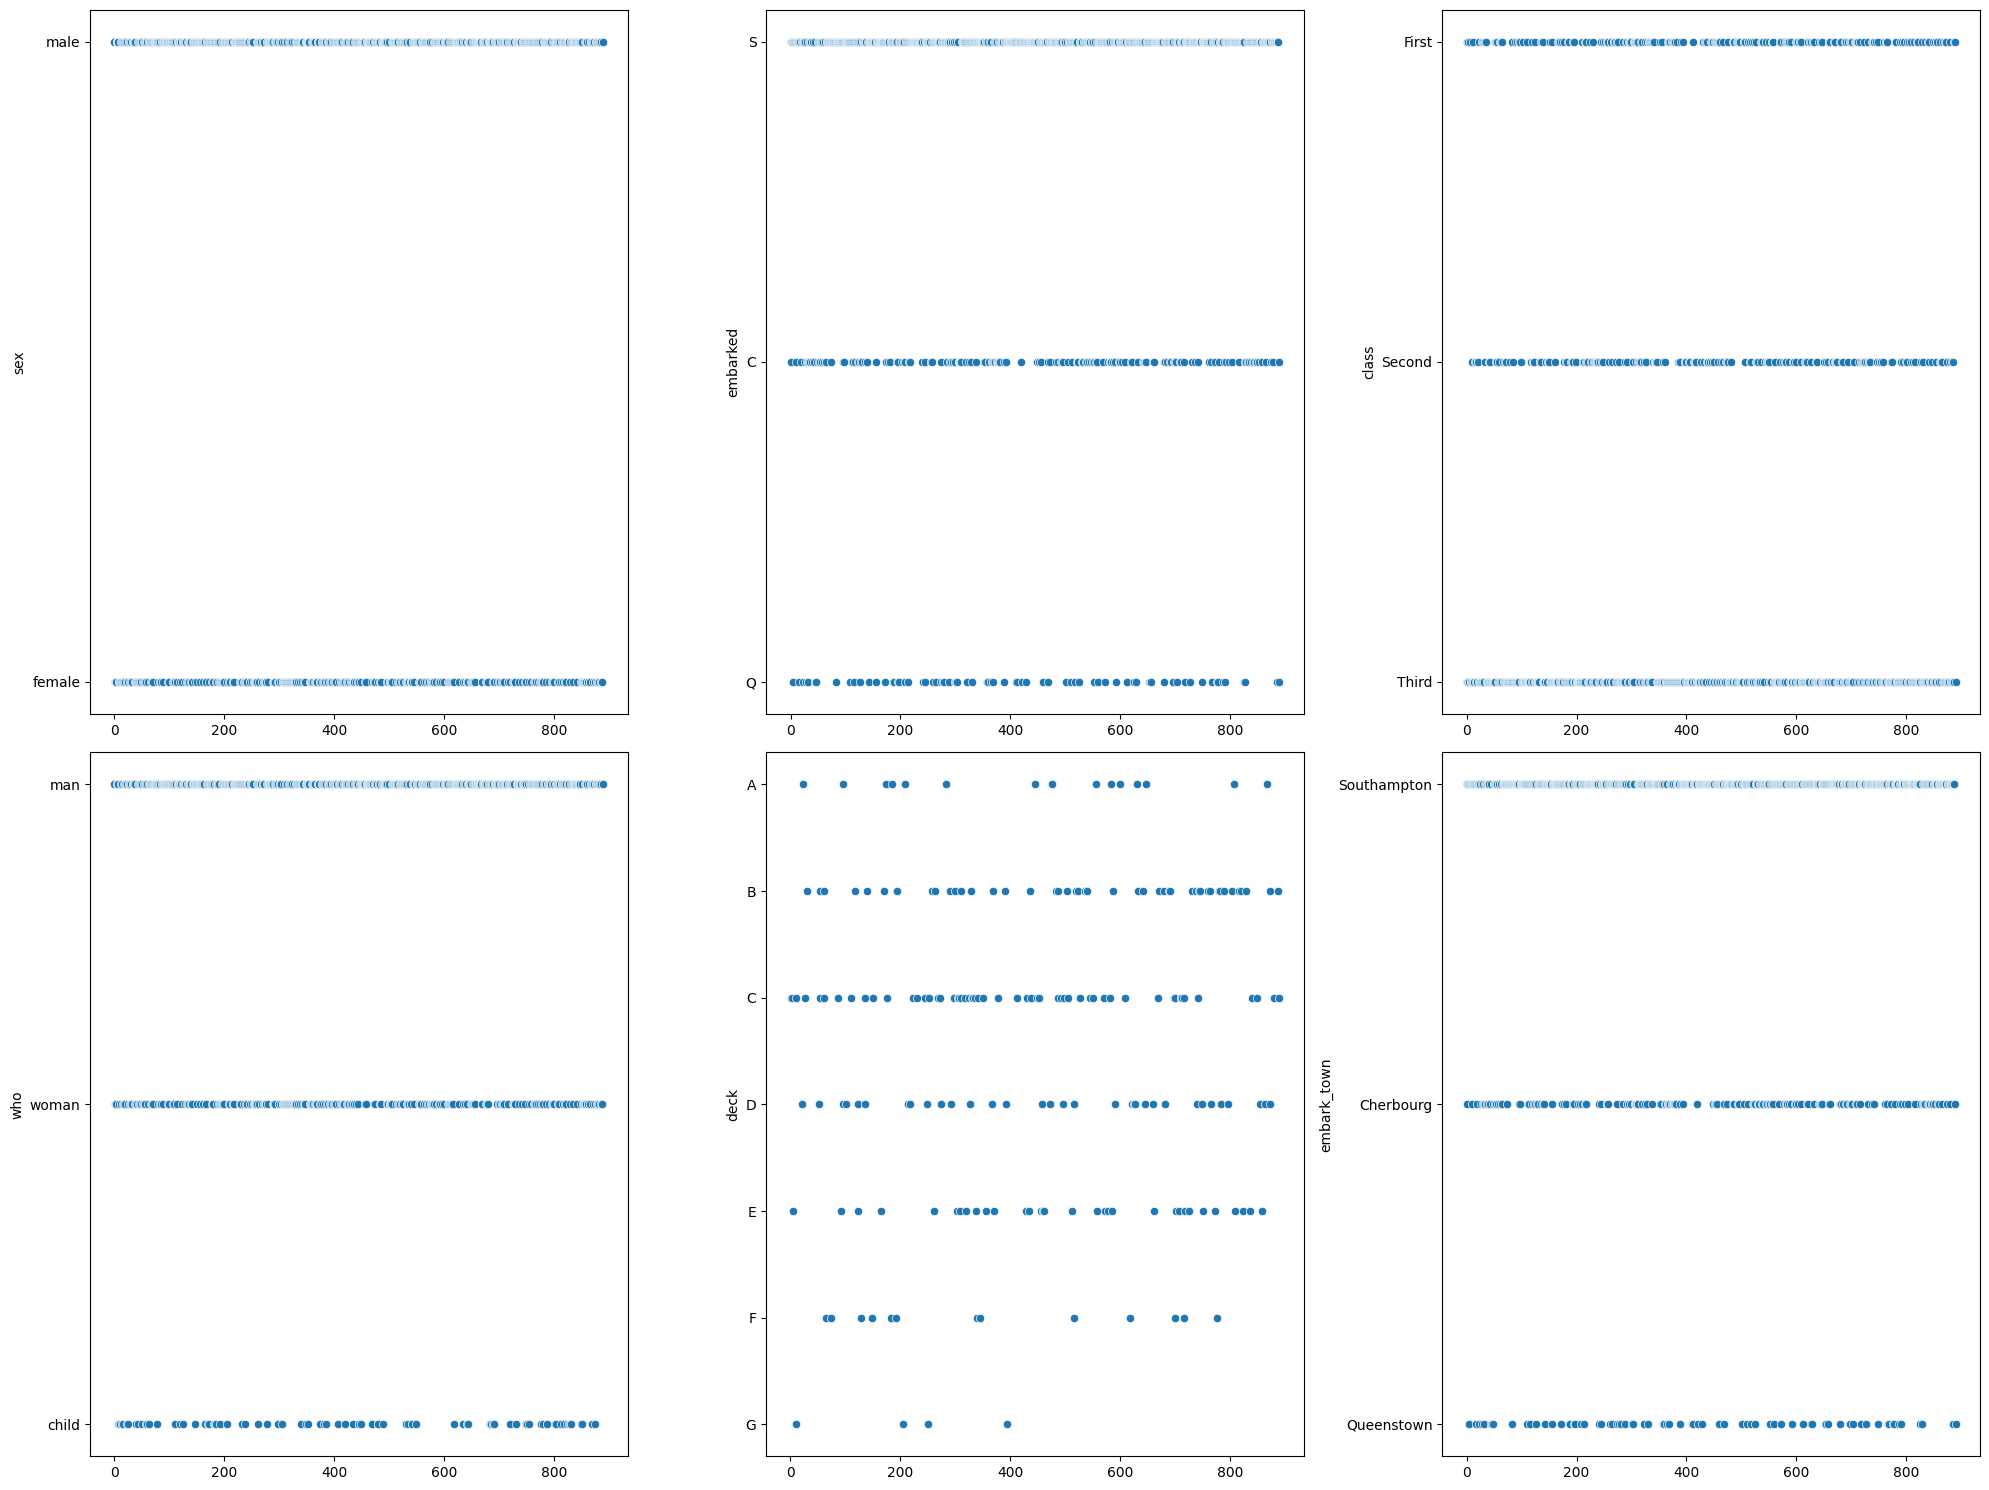

In [228]:
cat_cols = df[['sex','embarked', 'class', 'who', 'deck', 'embark_town','alive']]


plt.figure(figsize=(20,15))
plotnumber=1
for i in cat_cols:
    if plotnumber<=6:
        ax = plt.subplot(2,3, plotnumber)
        ax = sns.scatterplot(cat_cols[i])    
    plotnumber+=1
plt.tight_layout()
plt.show()

# <span style='color:Red'> Predicting Model

In [229]:
df['sex'] = df['sex'].replace({'male': 0, 'female': 1}).astype(int)
# df['embarked'].replace({'S':0, 'C':1, 'Q':2}, inplace=True).astype(int)
# df['deck'].replace({'C':0, 'E':1, 'G':2, 'D':3, 'A':4, 'B':5, 'F':6}, inplace=True).astype(int)

In [230]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    int64   
 3   age          891 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(5), str(4)
memory usage: 96.3 KB


In [231]:
X = df[['pclass', 'sex', 'sibsp', 'parch','age']]
y = df['survived']

In [232]:
from sklearn.preprocessing import StandardScaler

In [233]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [234]:
X.isna().sum()

pclass    0
sex       0
sibsp     0
parch     0
age       0
dtype: int64

## <span style='color:Yellow'> 1. Logistic Regression

In [235]:
from sklearn.linear_model import LogisticRegression

In [236]:
LR = LogisticRegression()


In [237]:
LR.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [238]:
LR_pred = LR.predict(X_test)

In [239]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, LR_pred)

0.8268156424581006

In [240]:
from sklearn.datasets import make_classification
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

X, y = make_classification(random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)
pipe = make_pipeline(StandardScaler(), LogisticRegression())
pipe.fit(X_train, y_train)  # apply scaling on training data

pipe.score(X_test, y_test)  


0.96

## <span style='color:Yellow'> 2. SVM

In [241]:
from sklearn.svm import SVC

X, y = make_classification(random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)
pipe = make_pipeline(StandardScaler(), SVC())
pipe.fit(X_train, y_train)  # apply scaling on training data

pipe.score(X_test, y_test)  

0.92

## <span style='color:Yellow'> 3. Decision Tree Classifier

In [242]:
from sklearn.tree import DecisionTreeClassifier
X, y = make_classification(random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)
pipe = make_pipeline(StandardScaler(), DecisionTreeClassifier())
pipe.fit(X_train, y_train)  # apply scaling on training data

pipe.score(X_test, y_test)  

0.92

## <span style='color:Yellow'> 4. Random Forest Classifier

In [243]:
from sklearn.ensemble import RandomForestClassifier
X, y = make_classification(random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)
pipe = make_pipeline(StandardScaler(), RandomForestClassifier())
pipe.fit(X_train, y_train)  # apply scaling on training data

pipe.score(X_test, y_test)  

0.84

## <span style='color:Yellow'> 5. KNeighbour_Classifier

In [244]:
from sklearn.neighbors import KNeighborsClassifier
X, y = make_classification(random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)
pipe = make_pipeline(StandardScaler(), KNeighborsClassifier())
pipe.fit(X_train, y_train)  # apply scaling on training data

pipe.score(X_test, y_test)  

0.84

## <span style='color:Yellow'> 6.MLP Classifier

In [245]:
from sklearn.neural_network import MLPClassifier
X, y = make_classification(random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)
pipe = make_pipeline(StandardScaler(), MLPClassifier())
pipe.fit(X_train, y_train)  # apply scaling on training data

pipe.score(X_test, y_test)  

0.84

## <span style='color:Yellow'> 7. XGB_Classifier

In [246]:
from xgboost import XGBClassifier
X, y = make_classification(random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)
pipe = make_pipeline(StandardScaler(), XGBClassifier())
pipe.fit(X_train, y_train)  # apply scaling on training data

pipe.score(X_test, y_test)  

0.92

## <span style='color:Yellow'> 8. Gradient Boosting Classifier

In [247]:
from sklearn.ensemble import GradientBoostingClassifier
X, y = make_classification(random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)
pipe = make_pipeline(StandardScaler(), GradientBoostingClassifier())
pipe.fit(X_train, y_train)  # apply scaling on training data

pipe.score(X_test, y_test)  

0.92

## <span style='color:Yellow'> 9. Extra Trees Classifier

In [248]:
from sklearn.ensemble import ExtraTreesClassifier
X, y = make_classification(random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)
pipe = make_pipeline(StandardScaler(), ExtraTreesClassifier())
pipe.fit(X_train, y_train)  # apply scaling on training data

pipe.score(X_test, y_test)  

0.92

## <span style='color:Yellow'> 10. Ada Boost Classifier

In [249]:
from sklearn.ensemble import AdaBoostClassifier
X, y = make_classification(random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)
pipe = make_pipeline(StandardScaler(), AdaBoostClassifier())
pipe.fit(X_train, y_train)  # apply scaling on training data

pipe.score(X_test, y_test)  

0.92

In [250]:
import pickle
pickle.dump(LR, open('model.pkl','wb'))

## Accuracy Scores

<li>Logistic Regression --> 96%
<li>Support Vector Classifier --> 92%
<li>Decision Tree Classifier --> 92%
<li>Random Forest Classifier --> 84%
<li>KNeighbour Classifier --> 84%
<li>MLP Classifier --> 92%
<li>XGB Classifier --> 92%
<li>Gradient Boosting Classifier --> 92%
<li>Extra Tree Classifier --> 92%
<li>Ada Boost Classifier --> 92%